# `fit4functionaav9.csv` — candidate "new variant" NGS/PCR artifacts

Hypothesis to check: `Production1`/`Production2` are two INDEPENDENT codon-level DNA
constructs (`CodonRep1`/`CodonRep2`) for the same designed amino-acid variant (`AA`), each
measured once. If the true viability of the amino-acid sequence were the only thing driving
the signal, both replicates should broadly agree (they do, on average -- see
`log_enrichment_histograms.ipynb`/`ProfileMLP_train_Production1_test_Production2.ipynb`,
replicate-ceiling Pearson r ~ 0.89). A variant that is completely undetected in ONE replicate
(`Production_x = 0`, i.e. zero vector reads at that checkpoint) but clearly in the "fit"
population in the OTHER replicate is a much sharper disagreement than typical replicate
noise -- one candidate explanation (this notebook doesn't try to confirm it directly, see
caveat at the bottom): a PCR/synthesis/sequencing error changed that specific codon
construct's actual DNA into something that no longer represents the intended amino-acid
sequence, so the two "replicates" of the same design silently stopped measuring the same
thing.

Operational definition used below: `Production_x == 0` (undetected) AND `Production_y` above
a "fit" threshold (auto-detected from the bimodal `log2(Production1)` distribution, same
mode/valley KDE approach as `aav_viability_test/AAV9_profile_model.ipynb` section 1b).

## 0. Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../.."))
sys.path.insert(0, os.path.abspath("."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

df = pd.read_csv("fit4functionaav9.csv")
print(f"{len(df):,} rows, columns: {list(df.columns)}")
df["Label"].value_counts()

74,464 rows, columns: ['AA', 'CodonRep1', 'CodonRep2', 'Label', 'Production1', 'Production2', 'Production']


Label
Designed       64477
Calibration     9987
Name: count, dtype: int64

## 1. Fit / non-fit threshold (auto-detected from the bimodal distribution)

Same histogram-bin mode-detection as elsewhere in this project (`find_peaks` applied directly
to binned counts, no KDE), applied to `log2(Production1)` (finite, >0 rows only). Two modes
are expected (see `log_enrichment_histograms.ipynb`): a "non-fit" cluster around a strongly
negative log2, and a "fit" cluster near/above 0. The valley between them is used as the
"definitely fit" threshold below.

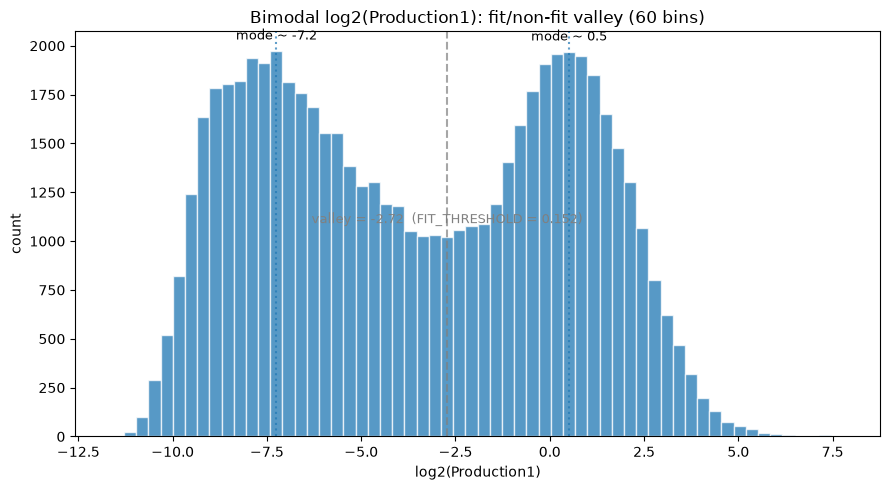

FIT_THRESHOLD = 0.1515  (log2 = -2.722)


In [2]:
p1 = df["Production1"].to_numpy(dtype=float)
p2 = df["Production2"].to_numpy(dtype=float)

valid1 = np.isfinite(p1) & (p1 > 0)
log2_valid1 = np.log2(p1[valid1])

N_BINS = 60  # same bin count as log_enrichment_histograms.ipynb / AAV9_fitting_protocol.ipynb
counts, edges = np.histogram(log2_valid1, bins=N_BINS)
centers = (edges[:-1] + edges[1:]) / 2
peaks, _ = find_peaks(counts, prominence=counts.max() * 0.05)
assert len(peaks) >= 2, f"expected a bimodal distribution, found {len(peaks)} mode(s)"

lo, hi = peaks[0], peaks[-1]
valley_idx = lo + np.argmin(counts[lo:hi + 1])
valley_log2 = centers[valley_idx]
FIT_THRESHOLD = 2 ** valley_log2

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(centers, counts, width=(edges[1] - edges[0]), color="tab:blue", alpha=0.75, edgecolor="white")
for p in peaks:
    ax.axvline(centers[p], color="tab:blue", linestyle=":", alpha=0.7)
    ax.annotate(f"mode ~ {centers[p]:.1f}", (centers[p], counts[p]), textcoords="offset points",
                xytext=(0, 8), ha="center", fontsize=9)
ax.axvline(valley_log2, color="gray", linestyle="--", alpha=0.7)
ax.annotate(f"valley = {valley_log2:.2f}  (FIT_THRESHOLD = {FIT_THRESHOLD:.3f})",
            (valley_log2, counts[valley_idx]), textcoords="offset points",
            xytext=(0, 10), ha="center", fontsize=9, color="gray")
ax.set_xlabel("log2(Production1)")
ax.set_ylabel("count")
ax.set_title(f"Bimodal log2(Production1): fit/non-fit valley ({N_BINS} bins)")
fig.tight_layout()
plt.show()

print(f"FIT_THRESHOLD = {FIT_THRESHOLD:.4f}  (log2 = {valley_log2:.3f})")

## 2. Discordant variants: zero in one replicate, clearly "fit" in the other

- `disc_1to2`: `Production1 == 0` (undetected) AND `Production2 > FIT_THRESHOLD`
- `disc_2to1`: `Production2 == 0` AND `Production1 > FIT_THRESHOLD`

In [3]:
zero1, zero2 = (p1 == 0), (p2 == 0)
fit1 = np.isfinite(p1) & (p1 > FIT_THRESHOLD)
fit2 = np.isfinite(p2) & (p2 > FIT_THRESHOLD)

disc_1to2 = zero1 & fit2
disc_2to1 = zero2 & fit1
discordant = disc_1to2 | disc_2to1

print(f"total rows:                              {len(df):,}")
print(f"Production1 == 0:                        {zero1.sum():,}")
print(f"Production2 == 0:                        {zero2.sum():,}")
print(f"discordant (Production1=0, Production2 fit): {disc_1to2.sum():,}")
print(f"discordant (Production2=0, Production1 fit): {disc_2to1.sum():,}")
print(f"TOTAL discordant:                        {discordant.sum():,}  ({discordant.mean():.3%} of all rows)")

print()
print("Label breakdown, discordant vs overall:")
print(pd.DataFrame({
    "discordant": df.loc[discordant, "Label"].value_counts(),
    "overall":    df["Label"].value_counts(),
}).assign(discordant_rate=lambda d: d["discordant"] / d["overall"]))

total rows:                              74,464
Production1 == 0:                        12,680
Production2 == 0:                        12,805
discordant (Production1=0, Production2 fit): 27
discordant (Production2=0, Production1 fit): 42
TOTAL discordant:                        69  (0.093% of all rows)

Label breakdown, discordant vs overall:
             discordant  overall  discordant_rate
Label                                            
Designed             64    64477         0.000993
Calibration           5     9987         0.000501


## 3. How extreme is this, relative to normal replicate noise?

Among rows where BOTH replicates give a valid (finite, >0) measurement, `|log2(Production1)
- log2(Production2)|` is already noisy on its own (this is the same noise floor behind the
replicate-ceiling `r ~ 0.89` seen elsewhere). Reusing that same scale with a small pseudocount
for the exact-zero side shows where the discordant rows actually sit on it -- if they're just
sitting at the noisy tail of ordinary disagreement, "new variant" is a much weaker story than
if they're far beyond anything normal noise produces.

In [4]:
both_valid = np.isfinite(p1) & (p1 > 0) & np.isfinite(p2) & (p2 > 0)
normal_diff = np.abs(np.log2(p1[both_valid]) - np.log2(p2[both_valid]))
print("abs log2 diff, BOTH replicates valid (normal noise floor):")
print(f"  median={np.median(normal_diff):.2f}  p95={np.percentile(normal_diff, 95):.2f}  "
      f"p99={np.percentile(normal_diff, 99):.2f}  max={normal_diff.max():.2f}")

EPS = 1e-3  # pseudocount, only for placing the hard-zero side on the same log2 scale
disc_diff = np.abs(np.log2(np.where(p1[discordant] == 0, EPS, p1[discordant])) -
                    np.log2(np.where(p2[discordant] == 0, EPS, p2[discordant])))
print(f"\nabs log2 diff (pseudocount={EPS}), discordant rows only:")
print(f"  median={np.median(disc_diff):.2f}  min={disc_diff.min():.2f}  max={disc_diff.max():.2f}")
print(f"  -> {(disc_diff > np.percentile(normal_diff, 99)).mean():.0%} of discordant rows exceed "
      f"the p99 of normal replicate disagreement")

abs log2 diff, BOTH replicates valid (normal noise floor):
  median=1.12  p95=3.64  p99=5.07  max=9.79

abs log2 diff (pseudocount=0.001), discordant rows only:
  median=8.17  min=7.24  max=14.00
  -> 100% of discordant rows exceed the p99 of normal replicate disagreement


## 4. Scatter: where the discordant points sit

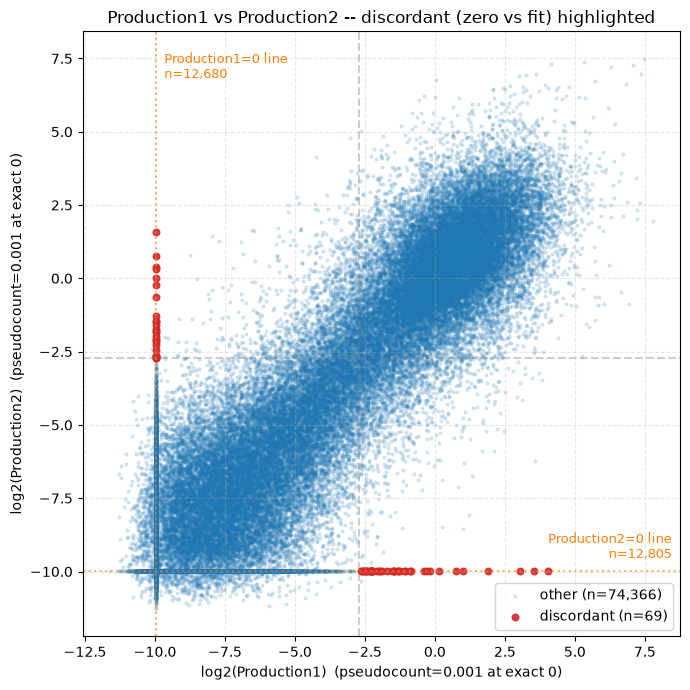

variants on the Production1=0 line (x=-9.97): 12,680  (17.03% of all rows)
variants on the Production2=0 line (y=-9.97): 12,805  (17.20% of all rows)
variants on BOTH lines (Production1=0 AND Production2=0): 5,664


In [5]:
EPS = 1e-3
log2_eps = np.log2(EPS)  # ~ -9.97, where every exact-zero row piles up on the axes below
log2_p1_plot = np.log2(np.where(p1 == 0, EPS, np.where(np.isfinite(p1), p1, np.nan)))
log2_p2_plot = np.log2(np.where(p2 == 0, EPS, np.where(np.isfinite(p2), p2, np.nan)))
finite_plot = np.isfinite(log2_p1_plot) & np.isfinite(log2_p2_plot)

fig, ax = plt.subplots(figsize=(7, 7))
bg = finite_plot & ~discordant
ax.scatter(log2_p1_plot[bg], log2_p2_plot[bg], s=4, alpha=0.15, color="tab:blue", label=f"other (n={bg.sum():,})")
ax.scatter(log2_p1_plot[discordant], log2_p2_plot[discordant], s=22, alpha=0.9, color="tab:red",
           label=f"discordant (n={discordant.sum():,})")
ax.axhline(valley_log2, color="gray", linestyle="--", alpha=0.4)
ax.axvline(valley_log2, color="gray", linestyle="--", alpha=0.4)

# Pseudocount pile-up lines: every Production1==0 (resp. Production2==0) row lands exactly
# on x=log2_eps (resp. y=log2_eps) regardless of its actual value on the other axis -- count
# of variants sitting on each line, not just how many are ALSO flagged discordant above.
ax.axvline(log2_eps, color="tab:orange", linestyle=":", alpha=0.6)
ax.axhline(log2_eps, color="tab:orange", linestyle=":", alpha=0.6)
ax.annotate(f"Production1=0 line\nn={zero1.sum():,}", (log2_eps, ax.get_ylim()[1]),
            textcoords="offset points", xytext=(6, -14), ha="left", va="top", fontsize=9, color="tab:orange")
ax.annotate(f"Production2=0 line\nn={zero2.sum():,}", (ax.get_xlim()[1], log2_eps),
            textcoords="offset points", xytext=(-6, 6), ha="right", va="bottom", fontsize=9, color="tab:orange")

ax.set_xlabel(f"log2(Production1)  (pseudocount={EPS} at exact 0)")
ax.set_ylabel(f"log2(Production2)  (pseudocount={EPS} at exact 0)")
ax.set_title("Production1 vs Production2 -- discordant (zero vs fit) highlighted")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.3)
fig.tight_layout()
plt.show()

print(f"variants on the Production1=0 line (x={log2_eps:.2f}): {zero1.sum():,}  "
      f"({zero1.sum() / len(df):.2%} of all rows)")
print(f"variants on the Production2=0 line (y={log2_eps:.2f}): {zero2.sum():,}  "
      f"({zero2.sum() / len(df):.2%} of all rows)")
print(f"variants on BOTH lines (Production1=0 AND Production2=0): {(zero1 & zero2).sum():,}")

## 5. Most extreme discordant variants

In [6]:
top = df.loc[discordant, ["AA", "CodonRep1", "CodonRep2", "Label", "Production1", "Production2"]].copy()
top["log2_high_side"] = np.where(top["Production1"] == 0, np.log2(top["Production2"]), np.log2(top["Production1"]))
top = top.sort_values("log2_high_side", ascending=False).reset_index(drop=True)
top.head(20)

/home/spark0735/MERLIN_YASSINE/Directed-Evolution-loop/.venv/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)


,AA,CodonRep1,CodonRep2,Label,Production1,Production2,log2_high_side
0,AQLPVPH,GCTCAGTTGCCGGTTCCGCAT,GCACAACTGCCTGTGCCACAC,Designed,16.380726,0.000000,4.033927
1,AGHNTTP,GCCGGACATAACACAACCCCT,GCTGGCCACAATACCACGCCC,Designed,11.718515,0.000000,3.550718
2,HPPGLGT,CATCCACCTGGCCTTGGAACC,CACCCTCCGGGTCTGGGCACA,Designed,8.210911,0.000000,3.037542
3,TNMATQR,ACAAACATGGCGACACAGCGG,ACTAATATGGCCACCCAAAGG,Designed,3.761673,0.000000,1.911374
4,TRGLDPR,ACCCGCGGATTAGACCCACGG,ACGCGGGGTTTGGATCCGCGC,Designed,0.000000,3.003170,1.586486
5,GAQPLQQ,GGAGCCCAACCGCTACAACAA,GGCGCGCAGCCACTGCAGCAG,Designed,2.024419,0.000000,1.017508
6,TDNGWPP,ACCGACAACGGCTGGCCACCC,ACTGATAATGGGTGGCCCCCT,Calibration,0.000000,1.704963,0.769740
7,ERRAAQP,GAACGCCGAGCAGCTCAGCCT,GAGCGGCGGGCGGCCCAACCC,Designed,1.688984,0.000000,0.756156
8,WHAHSHV,TGGCATGCACACTCCCATGTA,TGGCACGCCCATTCACACGTG,Designed,0.000000,1.317778,0.398107
9,CRAVAQP,TGTCGTGCTGTAGCCCAACCC,TGCAGAGCGGTCGCGCAGCCA,Designed,0.000000,1.240747,0.311209


## Caveat

`CodonRep1`/`CodonRep2` here are the DESIGNED codon sequences for each construct, not the
actual post-error sequence NGS would have observed if a mutation really occurred -- this CSV
has no way to directly confirm a PCR/synthesis error happened on a specific discordant row.
What's shown above is a statistical flag (zero vs. clearly-fit, far beyond normal replicate
noise per section 3), not a confirmed mechanism. It's also a DIFFERENT noise source from the
cross-packaging discussion (`lib/cross_packaging_draft.py`): cross-packaging pushes a
non-viable variant's signal UP toward the fit population in a way correlated with
co-transfection/multiplicity; this pattern is a HARD zero in one specific replicate paired
with a strong signal in the other, consistent with the two "replicates" no longer measuring
the same physical DNA sequence at all, not just noisy detection of the same one. Only a small
fraction of the dataset is flagged this way (printed in section 2 above, `discordant.sum()` /
`discordant.mean()`) -- small enough to simply exclude from training if left unmodeled,
rather than needing a dedicated term in `sequence_classesV1.py` right away.